### Explore A Jain's IEI pipeline
### Julian Moran
### 2026-02-09

In [ ]:
import os

from dotenv import load_dotenv
from matplotlib.ticker import FuncFormatter
from matplotlib import pyplot as plt
from pathlib import Path
from typing import Tuple

import numpy as np
import polars as pl


# Env
pl.Config.set_tbl_rows(10)
load_dotenv("../.env")
INSTALL_PATH = os.environ["INSTALL_PATH"]

# Pipeline IO

Codebase at `/hpf/projects/CTrost/ajain/IEI_project/foldseek_AJ` 

1. DefenseFinder RefSeq IDs --> UniProt IDs
    - DefenseFinder: db of all bacterial genes implicated in antiphage systems
    - RefSeq bacterial accession IDs:   denote a bacterial immunoprotein; often begin with `WP`
    - UniProt access IDs:               denote a protein; e.g. `A0A7P0TAE1_HUMAN`

<br>

2. UniProt IDs --> Foldseek cluster ID

<br>

3. Foldseek cluster ID --> related human cluster ID

<br>

4. UniProt IDs --> UniprotKB annotations

<br>


# Questions

1. How does `01_RefSeq2Uniprot_mapping/` fit into the pipeline?
    - Are data in `01_RefSeq2Uniprot_mapping/` the output from pipeline step 2.?
    - Are data in `griid_gene_list/`, `gasdermin/`, `vipirin/`, `zorya/` prioritized subsets from `01_RefSeq2Uniprot_mapping/`?
    - If so, why are the subsets substantially larger than the original data?
    - `WP_063110969.1`, from `gasdermin/2025-07-26_gasdermin_annotated.xlsx`, is not in `data_local/01_RefSeq2Uniprot_mapping/2025-06-24_RefSeq2Uniprot_mapping.xlsx`

<br>

2. What is the relationship between each UniProt accession number and its corresponding cluster?
    - i.e. in datasets like `zorya/2025-07-27_zorya_annotated.tsv`?

<br>

3. Why do we see identical rows in the annotated data?
    - best to denote rows as `RefSeq_ID`,`UniProt_ID`,`FoldSeq_cluster`,`Similar_human_gene` 
    - e.g. in `zorya/2025-07-27_zorya_annotated.tsv`, see multiple rows for `WP_063192462.1`,`A0A142CZW3`,`A0A142CZW3`,`B4DLD8`

<br>

4. Human, Bacterial Domain Annotations ...
    - why is `Query_range` always a subset of the protein?
    - we suspect `Query_range` is not an alignment subset because `Human_prot_domain_match` is in turn a subset of `Query_range`
    - similar confusion for `Target_range`, `Bacterial_prot_domain_match`
    - alternatively, it is possible that `*_range` annotations do in fact represent aligned sequences, with `*_domain` annotations representing something extraneous (e.g. what sections of within the aligned regions match to uniquely human / bacterial domains?)

<br>


# Filtering criteria

1. Select for human proteins in same cluster as bacterial
    - `defense_system_cluster_id == cluster_id`
    - in annotated data, `defense_system_cluster_id` denotes the FoldSeek cluster that contains the query DefenseFinder protein
    - in annotated data, `cluster_id` denotes the most-similar target FoldSeek cluster containing a human protein 

<br>

2. Select for human proteins close in AA length to defense protein
    - col1: `Human_prot_total_length`
    - col2: `Bacterial_prot_total_length`
    - compute symmetric absolute percent difference (this appears to have been computed in `Overlap_ratio` col, albeit not symmetrically)
    - factor in percent overlap or percent match, here

<br>

3. Select for closest human genes that are in EAGLE definitive

<br>

# Plots

1. Heat map of e-values for strongly matching proteins

2. Histogram of AA length percent difference


In [6]:
# ============================================================
#                             Args
# ============================================================

args = {
    "data_file_foldseek_uniprot": f"{INSTALL_PATH}/data_local/02_FoldSeek_Results_w_Uniprot_matches/2025-07-26_batch_0_annotated.tsv",
    "data_file_GRIID": f"{INSTALL_PATH}/data_local/griid_gene_list/2025-07-30_data_filtered_for_griid_genes.tsv",
    "data_file_gasdermin": f"{INSTALL_PATH}/data_sync/gasdermin/2025-07-26_gasdermin_annotated.tsv",
    "data_file_vipirin": f"{INSTALL_PATH}/data_sync/viperin/2025-07-26_viperin_annotated.tsv",
    "data_file_zorya": f"{INSTALL_PATH}/data_local/zorya/2025-07-27_zorya_annotated.tsv"
}

In [7]:
# ============================================================
#                             In
# ============================================================

pl.Config.set_tbl_rows(10)

data_ann = {}
for key, path in args.items():
    if "data_file_" in key and not "foldseek" in key:
        data_key = key.replace("data_file_", "")
        data_ann[data_key] = pl.read_csv(
            args[key],
            has_header=True,
            separator="\t",
            schema_overrides={
                "duplicate_count": pl.Int64,
                "rank": pl.Int64,
                "evalue": pl.Float64,
                "cluFlag": pl.Int64,
                "fident": pl.Float64,
                "alnlen": pl.Int64,
                "mismatch": pl.Int64,
                "gapopen": pl.Float64,
                "qstart": pl.Int64,
                "qend": pl.Int64,
                "tstart": pl.Int64,
                "tend": pl.Int64,
                "evalue_foldseek": pl.Float64,
                "bits": pl.Int64,
                "Query_length": pl.Int64,
                "Human_prot_total_length": pl.Int64,
                "Human_domain_percentage": pl.Float64,
                "Query_percentage": pl.Float64,
                "Query_overlap_w_Human_protein": pl.Float64,
                "Target_length": pl.Int64,
                "Bacterial_prot_total_length": pl.Int64,
                "Bacterial_domain_percentage": pl.Float64,
                "Target_percentage": pl.Float64,
                "Target_overlap_w_Bacterial_protein": pl.Float64,
                "Bacterial_Human_Len_Ratio": pl.Float64,
                "Query_Target_Overlap_Length": pl.Float64,
                "Overlap_ratio": pl.Float64,
            },
            infer_schema_length=10000
        )

df_foldseek_uniprot = pl.read_csv(
    args["data_file_foldseek_uniprot"],
    separator="\t",
    has_header=True
)

df_foldseek_uniprot

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,i64,f64
"""WP_001223208.1""","""MazEF""","""MazEF""","""Shigella dysenteriae,Escherich…","""GCF_003017995_NZ_CP027368_MazE…","""GCF_002156845.1_NZ_CP021339_05…","""GCF_019428585.1_NZ_CP080119_01…",671,6,"""A0A024L8H8""","""S3FMY0""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""nan..nan""",null,null,null,null,null,null,null,null,"""nan..nan""",null,83,null,null,null,null,null,null,null,null,null
"""WP_003414296.1""","""Cas""","""CAS_Class1-Subtype-III-A""","""Mycobacterium tuberculosis,Myc…","""GCF_014884645_NZ_CP043996_CAS_…","""GCF_002975475.1_NZ_CP027035_02…","""GCF_013010385.1_NZ_CP053092_02…",264,23,"""A0A045ICU9""","""A0A1I6JKI6""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""nan..nan""",null,null,null,null,null,null,null,null,"""nan..nan""",null,124,null,null,null,null,null,null,null,null,null
"""WP_002885155.1""","""AbiE""","""AbiE""","""Klebsiella sp. P1927,Klebsiell…","""GCF_022354545_NZ_CP055087_AbiE…","""GCF_022494255.1_NZ_CP058743_04…","""GCF_003286975.1_NZ_CP030172_04…",454,12,"""A0A060VEP4""","""J1I8N4""","""A0A6J2X4D6""","""Q5TF85""",0.02082,1,0.098,297,214,0,179,475,10,247,0.001215,42,"""unreviewed""","""Q5TF85_HUMAN""","""polynucleotide adenylyltransfe…","""TENT5A FAM46A hCG_401094""","""Homo sapiens (Human)""",null,"""hCG_401094""","""TENT5A""","""FAM46A""","""UP000005640: Chromosome 6""",null,null,"""poly(A) RNA polymerase activit…","""poly(A) RNA polymerase activit…","""GO:1990817""",null,null,null,"""IPR012937; TET5.;""","""PTHR12974; PRION-LIKE- Q/N-RIC…","""PF07984; NTP_transf_7; 1.;""",null,"""SM01153; DUF1693; 1.;""",null,"""179.0..475.0""",297,523,null,null,null,null,null,null,"""10.0..247.0""",238,305,null,null,null,null,null,null,0.583174,238,0.780328
"""WP_002885155.1""","""AbiE""","""AbiE""","""Klebsiella sp. P1927,Klebsiell…","""GCF_022354545_NZ_CP055087_AbiE…","""GCF_022494255.1_NZ_CP058743_04…","""GCF_003286975.1_NZ_CP030172_04…",454,12,"""A0A060VEP4""","""J1I8N4""","""G1SF99""","""Q5VWP2""",0.08138,1,0.094,295,265,0,49,343,10,302,0.0009699,39,"""reviewed""","""TET5C_HUMAN""","""Terminal nucleotidyltransferas…","""TENT5C FAM46C""","""Homo sapiens (Human)""",null,null,"""TENT5C""","""FAM46C""","""UP000005640: Chromosome 1""","""in utero embryonic development…","""centrosome [GO:0005813]; cytop…","""centrosome [GO:0005813]; cytop…","""poly(A) RNA polymerase activit…","""GO:0001701; GO:0003723; GO

In [10]:
# ============================================================
#                Clean, stack annotated data
# ============================================================

def remove_dup_rows(df: pl.DataFrame) -> int:
    df_dup_counted = (
        df.group_by(df.columns)
        .len()
    )
    dups_count = (
        df_dup_counted.filter(pl.col("len") > 1)
        .select((pl.col("len") - 1).sum())
        .item()
    )
    print(f"Number of dup rows: {dups_count:,}")
    return df_dup_counted.drop("len"), dups_count


data_ann_cl = {}
for data_key, df in data_ann.items():
    data_ann_cl[data_key], dups_count = remove_dup_rows(df)

    # Write out cleaned version
    if dups_count > 0:
        key = [k for k in args if data_key in k][0]
        out_path = Path(args[key].replace(".tsv", "_cleaned.tsv"))
        data_ann_cl[data_key].write_csv(
            out_path,
            separator="\t",
            include_header=True
        )

df_ann_cl = pl.concat(
    [df for df in data_ann_cl.values()],
    how="diagonal"
)

print(f"Number of rows after cleaning, v-stacking: {len(df_ann_cl):,}")
df_ann_cl

Number of dup rows: 0
Number of dup rows: 0
Number of dup rows: 266
Number of dup rows: 40,578
Number of rows after cleaning, v-stacking: 321,575


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str
"""WP_000108735.1""","""RM""","""RM_Type_I""","""Escherichia coli""","""GCF_905332355_NZ_HG994850_RM_T…","""GCF_016776365.1_NZ_CP068802_01…","""GCF_900092615.1_NZ_LT601384_02…",24,179,"""A0A0Q2YF36""","""A0A1W9S900""","""S8A7C3""","""B4DL08""",0.0001372,2,0.086,453,394,0.0,2,433,369,821,0.000016,75,"""unreviewed""","""B4DL08_HUMAN""","""RNA helicase (EC 3.6.4.13)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,null,null,"""hydrolase activity [GO:0016787…","""hydrolase activity [GO:0016787…","""GO:0000166; GO:0003724; GO:001…","""cd18791; SF2_C_RHA; 1.;""","""3.40.50.300:FF:000007; Pre-mRN…","""1.20.120.1080; -; 1.;""3.40.50.…","""IPR011709; DEAD-box_helicase_O…","""PTHR18934; ATP-DEPENDENT RNA H…","""PF21010; HA2_C; 1.;""PF04408; H…","""PS00690; DEAH_ATP_HELICASE; 1.…","""SM00847; HA2; 1.;""SM00490; HEL…",null,"""2.0..433.0""",432,548,"""1..74""",98.65,16.9,78.83,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""369.0..821.0""",453,1031,null,null,null,null,null,null,1.881387,432.0,0.788321,"""No"""
"""WP_012028460.1""","""RM""","""RM_Type_I""","""Streptococcus suis""","""GCF_013488085_NZ_CP030017_RM_T…","""GCF_014874555.1_NZ_CP047248_01…","""GCF_019856355.1_NZ_CP082198_01…",21,182,"""D5AJP9""","""A0A7C4R6N8""","""A0A847FMI5""","""Q5HYK3""",0.02936,1,0.102,236,189,0.0,91,326,207,418,0.0002155,84,"""reviewed""","""COQ5_HUMAN""","""2-methoxy-6-polyprenyl-1,4-ben…","""COQ5""","""Homo sapiens (Human)""",null,null,"""COQ5""",null,"""UP000005640: Chromosome 12""","""methylation [GO:0032259]; ubiq…","""extrinsic component of mitocho…","""extrinsic component of mitocho…","""2-methoxy-6-polyprenyl-1,4-ben…","""GO:0005739; GO:0005743; GO:000…","""cd02440; AdoMet_MTases; 1.;""","""3.40.50.150:FF:000064; 2-metho…","""3.40.50.150; Vaccinia Virus pr…","""IPR029063; SAM-dependent_MTase…","""PTHR43591:SF24; 2-METHOXY-6-PO…","""PF01209; Ubie_methyltran; 1.;""","""PS51608; SAM_MT_UBIE; 1.;""PS01…",null,"""NP_115690.3; NM_032314.3.;""","""91.0..326.0""",236,327,null,null,null,null,null,null,"""207.0..418.0""",212,529,"""178..493""",67.09,100.0,40.08,"""['DNA methylase adenine-specif…","""['ECO:0000259|Pfam:PF02384']""",1.617737,212.0,0.648318,"""No"""
"""WP_000102010.1""","""CBASS""","""CBASS_I""","""Salmonella sp. SAL-020,Salmone…","""GCF_012050745_NZ_CP050721_CBAS…","""GCF_017372215.1_NZ_CP071690_01…","""GCF_005889955.1_NZ_CP040644_01…",22,181,"""A0A6C6ZTN4""","""A0A0F2L8W2""","""A0A060XGP9""","""A2RTX5""",0.1925,1,0.068,98,87,0.0,699,792,63,160,1.951,6,"""reviewed""","""SYTC2_HUMAN""","""Threonine--tRNA ligase 2, cyto…","""TARS3 TARSL2""","""Homo sapiens (Human)""",null,null,"""T

In [20]:
# ============================================================
#                     Filter annotated data
# ============================================================

def filter_data_ann(df: pl.DataFrame) -> pl.DataFrame:

    df = df.with_columns(
        ((pl.col("Bacterial_prot_total_length") / pl.col("Human_prot_total_length")) - 1)
        .abs()
        .alias("Protein_length_error")
    )

    df = df.filter(
        (pl.col("defense_system_cluster_id") == pl.col("cluster_id")) &
        (pl.col("Organism") == "Homo sapiens (Human)") &
        (pl.col("Protein_length_error").is_not_null & pl.col("Protein_length_error").is_not_nan)
    )
    print(f"N rows after filtering: {len(df)}")

    return df

# What are the species annotations for closest match?
print("Unique values for col `Species` before filtering:")
print(df_ann_cl["Organism"].unique())

df_ann_hs = filter_data_ann(df_ann_cl)
df_ann_hs

Unique values for col `Species` before filtering:
shape: (2,)
Series: 'Organism' [str]
[
	null
	"Homo sapiens (Human)"
]
N rows after filtering: 904


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene,Protein_length_error
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str,f64
"""WP_000434627.1""","""Eleos""","""Eleos""","""Escherichia coli""","""GCF_016776005_NZ_CP068823_Eleo…","""GCF_016775985.1_NZ_CP068827_02…","""GCF_020883255.1_NZ_CP086618_00…",27,176,"""Q9RFR9""","""A0A1I1GWW8""","""A0A1I1GWW8""","""A0A6Q8PGA3""",1.2200e-96,1,0.134,663,481,0.0,26,688,1,556,1.2880e-10,186,"""unreviewed""","""A0A6Q8PGA3_HUMAN""","""Mitofusin 2""","""MFN2""","""Homo sapiens (Human)""",null,null,"""MFN2""",null,"""UP000005640: Chromosome 1""","""mitochondrial fusion [GO:00080…","""mitochondrial outer membrane […","""mitochondrial outer membrane […","""GTP binding [GO:0005525]; GTPa…","""GO:0003924; GO:0005525; GO:000…","""cd09912; DLP_2; 1.;""","""3.40.50.300:FF:000214; Mitofus…","""3.40.50.300; P-loop containing…","""IPR045063; Dynamin_N.;""IPR0068…","""PTHR10465:SF1; MITOFUSIN-2; 1.…","""PF00350; Dynamin_N; 1.;""PF0479…","""PS51718; G_DYNAMIN_2; 1.;""",null,null,"""26.0..688.0""",663,690,"""93..342""",100.0,37.71,96.09,"""['Dynamin-type G']""","""['ECO:0000259|PROSITE:PS51718'…","""1.0..556.0""",556,577,"""212..555""",100.0,61.87,96.36,"""['Dynamin-like helical']""","""['ECO:0000259|Pfam:PF18709']""",0.836232,556.0,0.963605,"""Yes""",0.163768
"""WP_001328257.1""","""RM""","""RM_Type_II""","""Escherichia coli,Shigella flex…","""GCF_014904185_NZ_CP075469_RM_T…","""GCF_013282275.1_NZ_CP042878_00…","""GCF_013315675.1_NZ_CP054345_04…",24,179,"""O87740""","""A0A6I4ZMH2""","""A0A6I4ZMH2""","""B4DQZ2""",1.6640e-74,1,0.123,267,162,0.0,39,305,123,308,0.0007962,45,"""unreviewed""","""B4DQZ2_HUMAN""","""tRNA (cytosine(38)-C(5))-methy…",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""methylation [GO:0032259]""",null,"""methyltransferase activity [GO…","""methyltransferase activity [GO…","""GO:0008168; GO:0032259""",null,"""3.90.120.10:FF:000005; tRNA (C…","""3.90.120.10; DNA Methylase, su…","""IPR050750; C5-MTase.;""IPR00152…","""PTHR46098; TRNA (CYTOSINE(38)-…","""PF00145; DNA_methylase; 1.;""","""PS00095; C5_MTASE_2; 1.;""",null,"""NP_001307935.1; NM_001321006.1…","""39.0..305.0""",267,310,null,null,null,null,null,null,"""123.0..308.0""",186,309,null,null,null,null,null,null,0.996774,186.0,0.601942,"""No""",0.003226
"""WP_128105540.1""","""Zorya""","""Zorya_TypeI""","""Acetobacter oryzoeni""","""GCF_004014775_NZ_CP042808_Zory…","""GCF_004014775.2_NZ_CP042808_01…","""GCF_004014775.2_NZ_CP042808_01…",1,202,"""A0A5B9GHV7""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.211,558,417,0.0,408,937,455,1012,1.6930e-32,880,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chrom

Protein_length_error max: nan
Protein_length_error min: nan


ValueError: arange: cannot compute length

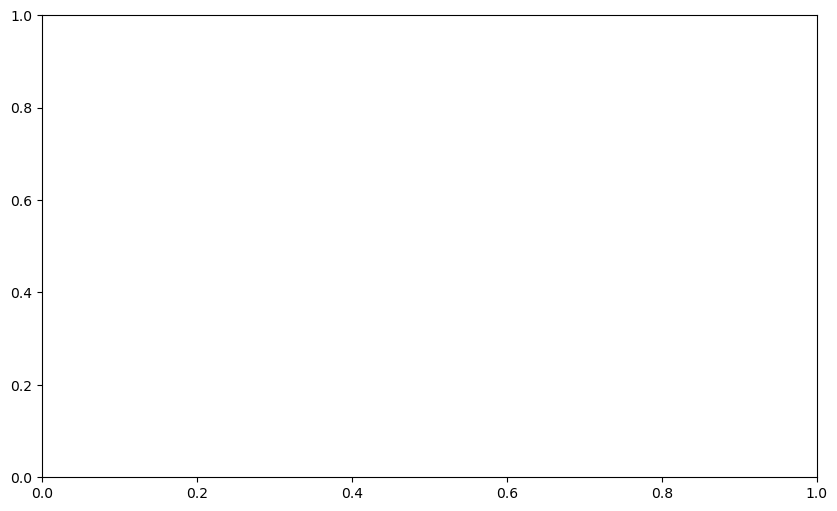

In [21]:
# ============================================================
#                       Length overlap
# ============================================================

# Compute overlap error
df_ann_cl = df_ann_cl.with_columns(
    ((pl.col("Bacterial_prot_total_length") / pl.col("Human_prot_total_length")) - 1)
    .abs()
    .alias("Protein_length_error")
)

# PLot histogram of `Protein_length_error`
def out_plot(
        figure: plt.Figure,
        out_path: str,
        svg: bool = True,
        png_dpi: int = 1080
) -> None:
    out_path = Path(out_path)
    if svg:
        figure.savefig(out_path.with_suffix(".svg"))
    if png_dpi:
        figure.savefig(out_path.with_suffix(".png"), dpi=png_dpi)
    return None

def plot_hist(
        df: pl.DataFrame,
        col_name: str,
        colour: str = "blue",
        alpha: float = 0.7,
        bin_width: float = 10.0,
        tick_interval: float = 0.1,
        exclude_zeros: bool = False,
        last_bin_leftSide: float = None,
        title: str = "EAGLE scores distribution",
        title_fontSize: int = 14,
        axis_label_fontSize: int = 10,
        xlabel: str = "EAGLE score",
        ylabel: str = "Gene count",
        dims: Tuple[int, int] = (10, 6),
        out_path: str = None
) -> None:
    
    var = df[col_name].to_numpy().astype(float)
    min, max = var.min(), var.max()
    print(f"{col_name} max: {max:,}")
    print(f"{col_name} min: {min:,}")
    fig, ax = plt.subplots(figsize=dims)

    if exclude_zeros:
        var = var[var != 0]
        min = var.min()
        print(f"Trimmed min {col_name}: {min}")
        
    if last_bin_leftSide is not None:
        var = np.where(
            var > last_bin_leftSide,
            last_bin_leftSide + bin_width,
            var
        )
        max = var.max()
        def _fmt(x, pos):
            if np.isclose(x, max - bin_width):
                return f"{int(last_bin_leftSide):,}+"
            return f"{int(x):,}"
        
        print(f"Trimmed max {col_name}: {max}")
    
    else:
        def _fmt(x, pos):
            return f"{int(x):,}"
            
    xticks = np.arange(0, max, tick_interval)
    xticks[0] = min

    edges = np.arange(0, max + bin_width, bin_width)
    edges[0] = min

    ax.hist(var, bins=edges, color=colour, alpha=alpha, label=f"n = {var.size:,}")
    ax.legend()
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.xaxis.set_major_formatter(FuncFormatter(_fmt))
    ax.set_xticks(xticks)
    ax.set_xlabel(xlabel, fontsize=axis_label_fontSize)
    ax.set_ylabel(ylabel, fontsize=axis_label_fontSize)
    ax.set_title(title, fontsize=title_fontSize)

    if out_path is not None:
        out_plot(figure=fig, out_path=out_path, svg=True, png_dpi=1080)

    plt.show()

plot_hist(
    df=df_ann_hs,
    col_name="Protein_length_error",
    tick_interval=0.1
)

In [25]:
df_ann_hs["Bacterial_prot_total_length"].null_count()

36